# PyTorch DNN Sentiment Classifier

Train a basic three-hidden-layer neural network on TF-IDF representations of the cleaned IMDB reviews. This establishes a neural baseline while preserving the same split and evaluation conventions used in the classical-model comparison.

In [2]:
# standard library
from copy import deepcopy
from pathlib import Path
import random
import sys
from time import perf_counter

# third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, RocCurveDisplay, roc_auc_score
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

# local
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

scripts_path = str(PROJECT_ROOT / "scripts")
if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

from imdb_dataset_helpers import clean_reviews, load_datasets
from imdb_model_helpers import split_labeled_reviews

## Configuration

The hidden widths follow a modest `128 → 64 → 32` funnel. Limiting TF-IDF to 20,000 features keeps the dense training batches and first linear layer manageable for this initial CPU-friendly experiment.

In [3]:
RANDOM_STATE = 42
VALIDATION_SIZE = 0.20
MAX_TFIDF_FEATURES = 20_000
HIDDEN_SIZES = (128, 64, 32)
DROPOUT = 0.30
BATCH_SIZE = 256
EPOCHS = 5
LEARNING_RATE = 1e-3

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

PyTorch: 2.2.2
Device: mps


## Load, clean, and split

Load a fresh copy, apply the shared cleanup, and reproduce Notebook 02's stratified split. The Kaggle test set remains untouched during model development.

In [4]:
train, _ = load_datasets()
train_clean = clean_reviews(train)

X_train_text, X_validation_text, y_train, y_validation = split_labeled_reviews(
    train_clean,
    validation_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
)

pd.DataFrame(
    {
        "rows": {"training": len(X_train_text), "validation": len(X_validation_text)},
        "positive_rate": {
            "training": y_train.mean(),
            "validation": y_validation.mean(),
        },
    }
)

Kaggle files already present; using: (project_root)/data/raw


,rows,positive_rate
training,19922,0.500803
validation,4981,0.500703


## TF-IDF features and data loaders

Fit TF-IDF only on the training fold. The matrices stay sparse in memory and each mini-batch is converted to a dense tensor only when PyTorch requests it.

In [5]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=MAX_TFIDF_FEATURES,
    sublinear_tf=True,
    dtype=np.float32,
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_validation_tfidf = tfidf.transform(X_validation_text)
X_train_tfidf.shape, X_validation_tfidf.shape

((19922, 20000), (4981, 20000))

In [6]:
class SparseReviewDataset(Dataset):
    """Expose sparse review features as individual dense PyTorch tensors."""

    def __init__(self, features, labels):
        self.features = features
        self.labels = np.asarray(labels, dtype=np.float32)

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, index):
        features = torch.from_numpy(self.features[index].toarray().ravel())
        label = torch.tensor(self.labels[index], dtype=torch.float32)
        return features, label


train_dataset = SparseReviewDataset(X_train_tfidf, y_train)
validation_dataset = SparseReviewDataset(X_validation_tfidf, y_validation)

loader_generator = torch.Generator().manual_seed(RANDOM_STATE)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
)

## Three-layer DNN

Each hidden layer uses ReLU activation and dropout. The final layer returns one raw logit; `BCEWithLogitsLoss` applies the numerically stable sigmoid-plus-binary-cross-entropy calculation during training.

In [7]:
class SentimentDNN(nn.Module):
    """A three-hidden-layer feed-forward sentiment classifier."""

    def __init__(self, input_size, hidden_sizes, dropout):
        super().__init__()
        layers = []
        previous_size = input_size
        for hidden_size in hidden_sizes:
            layers.extend(
                [
                    nn.Linear(previous_size, hidden_size),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                ]
            )
            previous_size = hidden_size
        layers.append(nn.Linear(previous_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, features):
        return self.network(features).squeeze(1)


model = SentimentDNN(
    input_size=X_train_tfidf.shape[1],
    hidden_sizes=HIDDEN_SIZES,
    dropout=DROPOUT,
).to(device)
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

model

SentimentDNN(
  (network): Sequential(
    (0): Linear(in_features=20000, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

## Train

Track both training and validation loss and retain the weights from the lowest validation-loss epoch.

In [8]:
def calculate_loss(data_loader, training):
    model.train(training)
    running_loss = 0.0

    for features, labels in data_loader:
        features = features.to(device)
        labels = labels.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(features)
            loss = loss_function(logits, labels)
            if training:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * labels.size(0)

    return running_loss / len(data_loader.dataset)


history = []
best_validation_loss = float("inf")
best_model_state = None
training_start = perf_counter()

for epoch in range(1, EPOCHS + 1):
    train_loss = calculate_loss(train_loader, training=True)
    with torch.no_grad():
        validation_loss = calculate_loss(validation_loader, training=False)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "validation_loss": validation_loss,
        }
    )
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_model_state = deepcopy(model.state_dict())

    print(
        f"Epoch {epoch:>2}/{EPOCHS}: "
        f"train_loss={train_loss:.4f}, validation_loss={validation_loss:.4f}"
    )

training_seconds = perf_counter() - training_start
model.load_state_dict(best_model_state)
history = pd.DataFrame(history).set_index("epoch")
history

Epoch  1/5: train_loss=0.5250, validation_loss=0.2439
Epoch  2/5: train_loss=0.1723, validation_loss=0.2550
Epoch  3/5: train_loss=0.0786, validation_loss=0.3263
Epoch  4/5: train_loss=0.0328, validation_loss=0.4198
Epoch  5/5: train_loss=0.0135, validation_loss=0.4949


,train_loss,validation_loss
epoch,,
1,0.525020,0.243886
2,0.172341,0.254966
3,0.078595,0.326320
4,0.032801,0.419787
5,0.013546,0.494933


## Learning curves

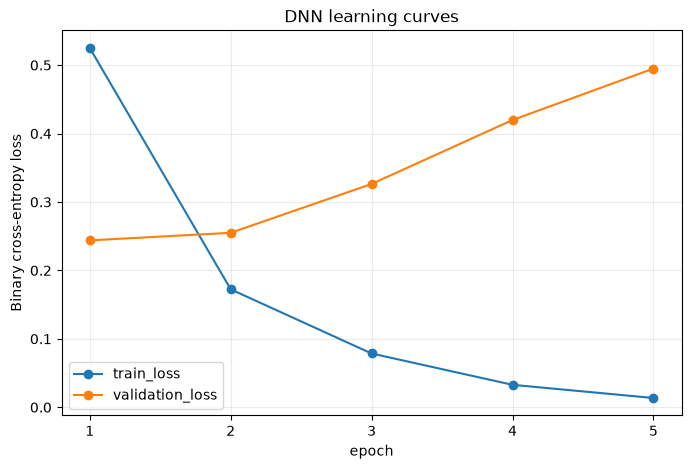

In [9]:
axis = history.plot(marker="o", figsize=(8, 5))
axis.set_title("DNN learning curves")
axis.set_ylabel("Binary cross-entropy loss")
axis.set_xticks(history.index)
axis.grid(alpha=0.25)
plt.show()

## Validation results

Evaluate the best-validation-loss weights using the same primary and supporting metrics as Notebook 02.

In [10]:
model.eval()
validation_probabilities = []

with torch.no_grad():
    for features, _ in validation_loader:
        logits = model(features.to(device))
        validation_probabilities.extend(torch.sigmoid(logits).cpu().numpy())

validation_probabilities = np.asarray(validation_probabilities)
validation_predictions = (validation_probabilities >= 0.5).astype(int)

dnn_result = pd.Series(
    {
        "roc_auc": roc_auc_score(y_validation, validation_probabilities),
        "accuracy": accuracy_score(y_validation, validation_predictions),
        "f1": f1_score(y_validation, validation_predictions),
        "features": X_train_tfidf.shape[1],
        "parameters": sum(parameter.numel() for parameter in model.parameters()),
        "training_seconds": training_seconds,
        "best_validation_loss": best_validation_loss,
    },
    name="TF-IDF + PyTorch DNN",
).to_frame("value")
dnn_result

,value
roc_auc,9.644361e-01
accuracy,8.992170e-01
f1,8.985859e-01
features,2.000000e+04
parameters,2.570497e+06
training_seconds,2.652315e+01
best_validation_loss,2.438863e-01


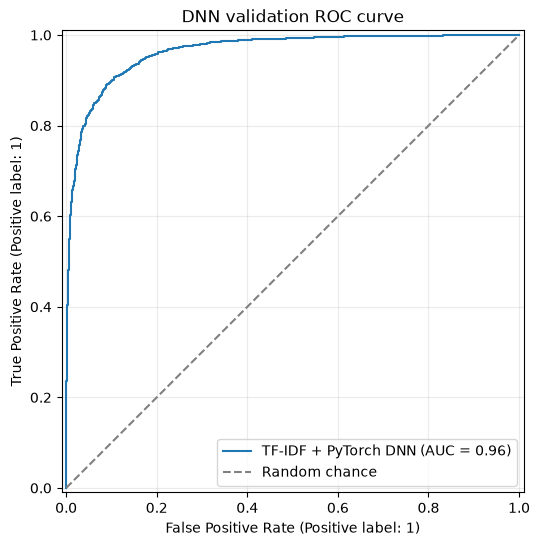

In [11]:
figure, axis = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_validation,
    validation_probabilities,
    name="TF-IDF + PyTorch DNN",
    ax=axis,
)
axis.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random chance")
axis.set_title("DNN validation ROC curve")
axis.grid(alpha=0.25)
axis.legend(loc="lower right")
plt.show()